In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load data
expr = pd.read_csv(r'D:\OmicsExpressionProteinCodingGenesTPMLogp1.csv', index_col=0)
model = pd.read_csv(r'D:\Model.csv')

print(expr.shape)
print(model.columns.tolist())

(1684, 19205)
['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber', 'ModelType', 'TissueOrigin', 'ModelDerivationMaterial', 'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType', 'PatientTreatmentDetails', 'Stage', 'StagingSystem', 'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating', 'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug', 'PublicComments', 'CCLEName', 'HCMIID', 'PediatricModelType', 'ModelAvailableInDbgap', 'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID', 'ModelIDAlias']


In [2]:
# Filter for skin cancer cell lines only
skin_model = model[model['OncotreeLineage'] == 'Skin']
print(f"Total skin cell lines: {len(skin_model)}")
print(skin_model['OncotreePrimaryDisease'].value_counts())

Total skin cell lines: 150
OncotreePrimaryDisease
Melanoma                             135
Merkel Cell Carcinoma                  8
Cutaneous Squamous Cell Carcinoma      6
Dermatofibrosarcoma Protuberans        1
Name: count, dtype: int64


In [3]:
# Get skin cell line IDs
skin_ids = skin_model['ModelID'].tolist()

# Filter expression data for skin cell lines
expr_skin = expr[expr.index.isin(skin_ids)]
print(f"Skin samples in expression data: {expr_skin.shape}")

# Check column names format for our genes
# Genes we need: MITF, SOX10, SOX9, JUN, ZEB1
genes_to_find = ['MITF', 'SOX10', 'SOX9', 'JUN', 'ZEB1']
matching_cols = [col for col in expr.columns if any(g == col.split(' ')[0] for g in genes_to_find)]
print(matching_cols)

Skin samples in expression data: (121, 19205)
['SOX10 (6663)', 'SOX9 (6662)', 'ZEB1 (6935)', 'JUN (3725)', 'MITF (4286)']


In [4]:
# Extract our 5 genes
mitf = expr_skin['MITF (4286)']
sox10 = expr_skin['SOX10 (6663)']
sox9 = expr_skin['SOX9 (6662)']
jun = expr_skin['JUN (3725)']
zeb1 = expr_skin['ZEB1 (6935)']

# Calculate proliferative and invasive scores
prolif_score = mitf + sox10
invasive_score = sox9 + jun + zeb1

# Spearman correlation
corr, pval = stats.spearmanr(prolif_score, invasive_score)
print(f"Spearman correlation: {corr:.3f}")
print(f"P-value: {pval:.2e}")

Spearman correlation: -0.651
P-value: 6.43e-16


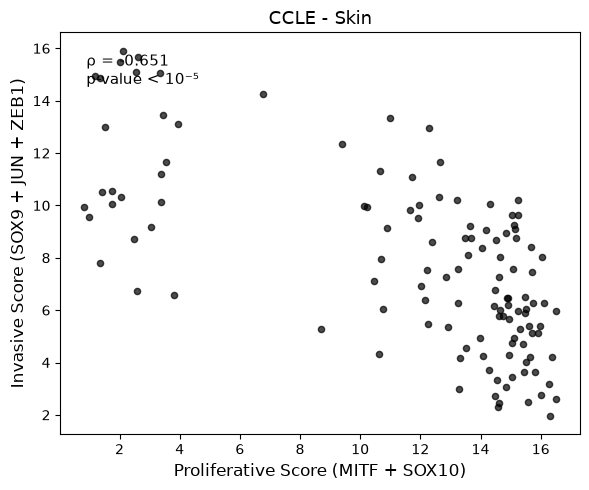

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(prolif_score, invasive_score, color='black', s=20, alpha=0.7)

# Add correlation text
plt.text(0.05, 0.95, f'ρ = {corr:.3f}\np-value < 10⁻⁵', 
         transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=11)

plt.xlabel('Proliferative Score (MITF + SOX10)', fontsize=12)
plt.ylabel('Invasive Score (SOX9 + JUN + ZEB1)', fontsize=12)
plt.title('CCLE - Skin', fontsize=13)

plt.tight_layout()
plt.savefig(r'D:\fig1d_CCLE.png', dpi=300)
plt.show()

In [7]:
# Load TCGA-SKCM data
tcga = pd.read_csv(r'D:\HiSeqV2_PANCAN', sep='\t', index_col=0)
print(tcga.shape)
print(tcga.index[:10])


(20530, 474)
Index(['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1',
       'REM1', 'MTVR2', 'RTN4RL2'],
      dtype='str', name='sample')


In [8]:
# Extract our 5 genes
genes = ['MITF', 'SOX10', 'SOX9', 'JUN', 'ZEB1']

# Check if genes exist
for g in genes:
    if g in tcga.index:
        print(f"{g} found")
    else:
        print(f"{g} NOT found")

MITF found
SOX10 found
SOX9 found
JUN found
ZEB1 found


In [9]:
# Extract gene expression and transpose (samples as rows)
tcga_genes = tcga.loc[genes].T

# Calculate scores
prolif_score_tcga = tcga_genes['MITF'] + tcga_genes['SOX10']
invasive_score_tcga = tcga_genes['SOX9'] + tcga_genes['JUN'] + tcga_genes['ZEB1']

# Spearman correlation
corr_tcga, pval_tcga = stats.spearmanr(prolif_score_tcga, invasive_score_tcga)
print(f"Spearman correlation: {corr_tcga:.3f}")
print(f"P-value: {pval_tcga:.2e}")


Spearman correlation: -0.368
P-value: 1.21e-16


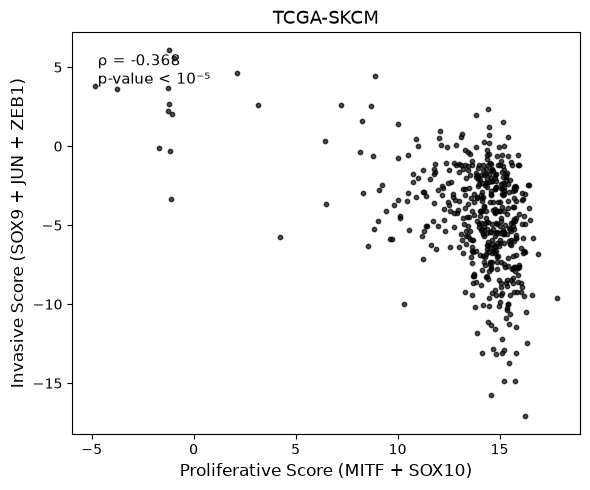

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(prolif_score_tcga, invasive_score_tcga, color='black', s=10, alpha=0.7)

plt.text(0.05, 0.95, f'ρ = {corr_tcga:.3f}\np-value < 10⁻⁵',
         transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=11)

plt.xlabel('Proliferative Score (MITF + SOX10)', fontsize=12)
plt.ylabel('Invasive Score (SOX9 + JUN + ZEB1)', fontsize=12)
plt.title('TCGA-SKCM', fontsize=13)

plt.tight_layout()
plt.savefig(r'D:\fig1d_TCGA.png', dpi=300)
plt.show()

In [11]:
# Load GSE115978 single cell TPM data
sc_data = pd.read_csv(r'D:\GSE115978_tpm.csv', index_col=0)
print(sc_data.shape)
print(sc_data.index[:10])

(23686, 7186)
Index(['C9orf152', 'RPS11', 'ELMO2', 'CREB3L1', 'PNMA1', 'MMP2', 'TMEM216',
       'TRAF3IP2-AS1', 'LRRC37A5P', 'LOC653712'],
      dtype='str')


In [12]:
# Check our genes exist
genes = ['MITF', 'SOX10', 'SOX9', 'JUN', 'ZEB1']
for g in genes:
    if g in sc_data.index:
        print(f"{g} found")
    else:
        print(f"{g} NOT found")

MITF found
SOX10 found
SOX9 found
JUN found
ZEB1 found


In [13]:
# Load cell annotations
annotations = pd.read_csv(r'D:\GSE115978_cell.annotations.csv', index_col=0)
print(annotations.shape)
print(annotations.head())
print(annotations.columns.tolist())

(7186, 6)
                                                samples cell.types  \
cells                                                                
cy78_CD45_neg_1_B04_S496_comb                     Mel78        Mal   
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb          Mel79        Mal   
CY88_5_B10_S694_comb                              Mel88        Mal   
cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb   Mel79        Mal   
cy78_CD45_neg_3_H06_S762_comb                     Mel78        Mal   

                                                 treatment.group  Cohort  \
cells                                                                      
cy78_CD45_neg_1_B04_S496_comb                     post.treatment  Tirosh   
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb         treatment.naive  Tirosh   
CY88_5_B10_S694_comb                              post.treatment  Tirosh   
cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb  treatment.naive  Tirosh   
cy78_CD45_neg_3_H06_S762_comb              

In [14]:
# Filter only malignant cells (Mal)
mal_cells = annotations[annotations['cell.types'] == 'Mal']
print(f"Malignant cells: {len(mal_cells)}")
print(mal_cells['samples'].value_counts())

Malignant cells: 2018
samples
Mel79       486
Mel102      169
Mel103      137
Mel88       124
Mel110      123
Mel78       120
Mel81       120
Mel89       100
Mel194       96
Mel106       94
Mel80        92
Mel129pa     92
Mel98        76
Mel71        62
Mel112       28
Mel128       26
Mel84        16
Mel53        14
Mel105       14
Mel60        12
Mel94         6
Mel82         6
Mel121.1      5
Name: count, dtype: int64


In [15]:
# Get malignant cell IDs
mal_cell_ids = mal_cells.index.tolist()

# Filter expression data for malignant cells only
sc_mal = sc_data[mal_cell_ids]
print(f"Shape: {sc_mal.shape}")

# Extract our 5 genes
sc_genes = sc_mal.loc[genes].T

# Calculate scores
prolif_score_sc = sc_genes['MITF'] + sc_genes['SOX10']
invasive_score_sc = sc_genes['SOX9'] + sc_genes['JUN'] + sc_genes['ZEB1']

# Add cell line info
prolif_score_sc = pd.DataFrame({'prolif': prolif_score_sc, 
                                 'invasive': invasive_score_sc,
                                 'cell_line': mal_cells.loc[mal_cell_ids, 'samples']})

print(prolif_score_sc.head())

Shape: (23686, 2018)
                                                   prolif  invasive cell_line
cy78_CD45_neg_1_B04_S496_comb                    6.811118  3.186342     Mel78
cy79_p4_CD45_neg_PDL1_neg_E11_S1115_comb         8.491704  5.274336     Mel79
CY88_5_B10_S694_comb                             9.052718  3.930643     Mel88
cy79_p1_CD45_neg_PDL1_pos_AS_C1_R1_F07_S67_comb  6.708362  6.560455     Mel79
cy78_CD45_neg_3_H06_S762_comb                    8.995316  2.375457     Mel78


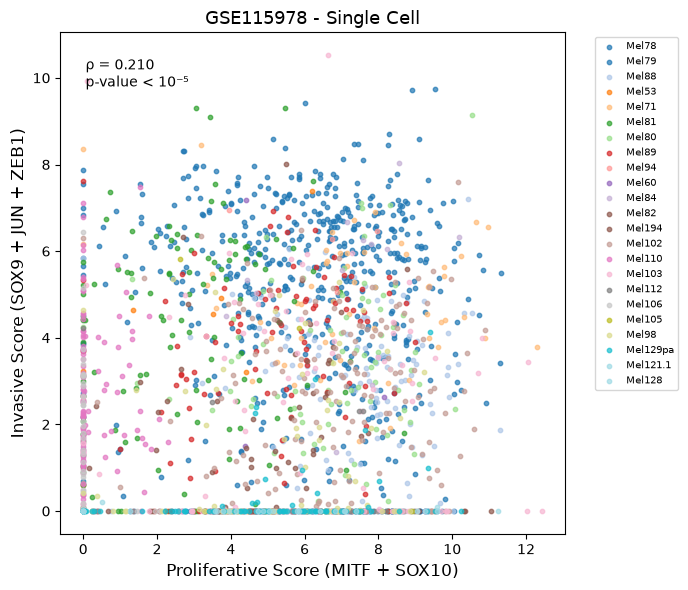

Spearman correlation: 0.210
P-value: 1.63e-21


In [16]:
# Create color map for cell lines
cell_lines = prolif_score_sc['cell_line'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(cell_lines)))
color_map = dict(zip(cell_lines, colors))

# Plot
plt.figure(figsize=(7, 6))
for cl in cell_lines:
    mask = prolif_score_sc['cell_line'] == cl
    plt.scatter(prolif_score_sc.loc[mask, 'prolif'],
                prolif_score_sc.loc[mask, 'invasive'],
                c=[color_map[cl]], label=cl, s=10, alpha=0.7)

# Correlation
corr_sc, pval_sc = stats.spearmanr(prolif_score_sc['prolif'], 
                                    prolif_score_sc['invasive'])
plt.text(0.05, 0.95, f'ρ = {corr_sc:.3f}\np-value < 10⁻⁵',
         transform=plt.gca().transAxes,
         verticalalignment='top', fontsize=10)

plt.xlabel('Proliferative Score (MITF + SOX10)', fontsize=12)
plt.ylabel('Invasive Score (SOX9 + JUN + ZEB1)', fontsize=12)
plt.title('GSE115978 - Single Cell', fontsize=13)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(r'D:\fig1f_i.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Spearman correlation: {corr_sc:.3f}")
print(f"P-value: {pval_sc:.2e}")

In [17]:
# Load GSE134432 bulk normalized data
bulk = pd.read_csv(r'D:\GSE134432_bulkRNASeq_33MelanomaBaselines_normalized_counts.tsv', 
                   sep='\t', index_col=0)
print(bulk.shape)
print(bulk.index[:10])

(55401, 33)
Index(['0R7H2P', '5S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M',
       'A2M-AS1', 'A2ML1', 'A2ML1-AS1'],
      dtype='str')


In [18]:
# Check our genes
for g in genes:
    if g in bulk.index:
        print(f"{g} found")
    else:
        print(f"{g} NOT found")

MITF found
SOX10 found
SOX9 found
JUN found
ZEB1 found


In [19]:
# Extract genes and transpose
bulk_genes = bulk.loc[genes].T

# Calculate scores
prolif_score_bulk = bulk_genes['MITF'] + bulk_genes['SOX10']
invasive_score_bulk = bulk_genes['SOX9'] + bulk_genes['JUN'] + bulk_genes['ZEB1']

# Check column names (these are the cell line names)
print(bulk_genes.index.tolist())

['HBL_12E93', 'MEL501', 'SKMEL28', 'MM029', 'MM031', 'MM032', 'MM034', 'MM043', 'MM050', 'MM054', 'MM057', 'MM070', 'MM074', 'MM087', 'MM094', 'MM098', 'MM099', 'MM116', 'MM118', 'MM125', 'MM129', 'MM131', 'MM142', 'MM146', 'MM147', 'MM148', 'MM150', 'MM152', 'MM161', 'MM163', 'MM164', 'MM165', 'MM168']


In [20]:
# Create dataframe with scores
scores_df = pd.DataFrame({
    'prolif_score': prolif_score_bulk,
    'invasive_score': invasive_score_bulk,
    'cell_line': bulk_genes.index
})

# Spearman correlation
corr_bulk, pval_bulk = stats.spearmanr(scores_df['prolif_score'], 
                                        scores_df['invasive_score'])
print(f"Spearman correlation: {corr_bulk:.3f}")
print(f"P-value: {pval_bulk:.2e}")
print(scores_df)

Spearman correlation: -0.701
P-value: 5.57e-06
           prolif_score  invasive_score  cell_line
HBL_12E93  13241.377868      218.804243  HBL_12E93
MEL501     19238.630212      145.112288     MEL501
SKMEL28     8452.545443      354.289688    SKMEL28
MM029        426.034730     1760.082875      MM029
MM031       9200.957660      458.668632      MM031
MM032      15024.108306     1315.225740      MM032
MM034      17170.430432      293.026889      MM034
MM043      25918.121123      309.843482      MM043
MM050      19445.381178      598.706050      MM050
MM054        777.159422     2105.376404      MM054
MM057      15372.551865      454.624895      MM057
MM070      15046.123368      533.386001      MM070
MM074      14992.935542      332.460905      MM074
MM087      14881.225345      487.396135      MM087
MM094      14303.291805      371.145399      MM094
MM098      28052.405704      525.780874      MM098
MM099        225.109571      796.090618      MM099
MM116        218.340182     1582.71

In [21]:
# Assign phenotypes based on scores
# High prolif + low invasive = proliferative (11000)
# High prolif + high invasive = intermediate (11001) 
# Low prolif + high invasive = invasive (00111)
# Medium both = neural crest like (01001)

prolif_median = scores_df['prolif_score'].median()
invasive_median = scores_df['invasive_score'].median()

def assign_phenotype(row):
    high_prolif = row['prolif_score'] > prolif_median
    high_invasive = row['invasive_score'] > invasive_median
    if high_prolif and not high_invasive:
        return '11000'
    elif high_prolif and high_invasive:
        return '11001'
    elif not high_prolif and high_invasive:
        return '00111'
    else:
        return '01001'

scores_df['phenotype'] = scores_df.apply(assign_phenotype, axis=1)
print(scores_df['phenotype'].value_counts())

phenotype
11000    14
00111    14
01001     3
11001     2
Name: count, dtype: int64


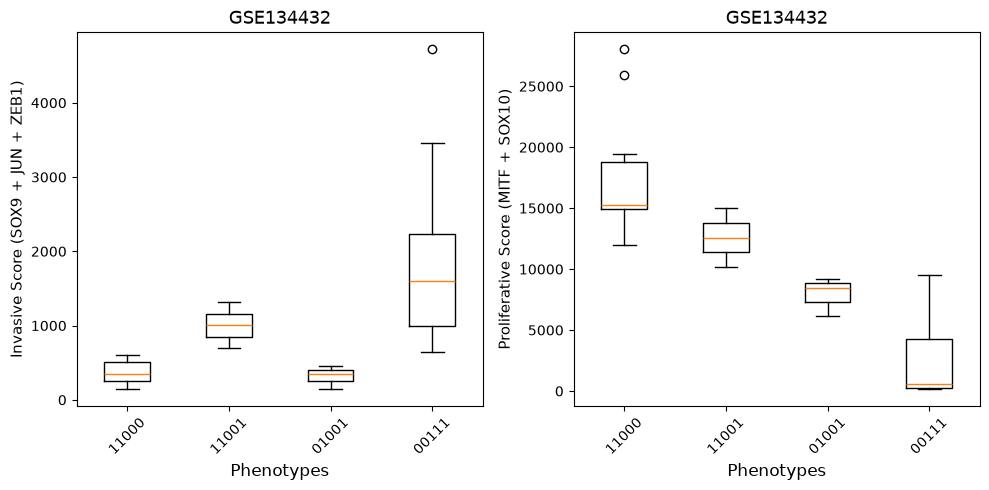

In [23]:
import matplotlib.pyplot as plt

# Define phenotype order as in paper
phenotype_order = ['11000', '11001', '01001', '00111']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Box plot 1 - Invasive scores
groups_invasive = [scores_df[scores_df['phenotype'] == p]['invasive_score'].values 
                   for p in phenotype_order]
ax1.boxplot(groups_invasive, tick_labels=phenotype_order)
ax1.set_xlabel('Phenotypes', fontsize=12)
ax1.set_ylabel('Invasive Score (SOX9 + JUN + ZEB1)', fontsize=11)
ax1.set_title('GSE134432', fontsize=13)
ax1.tick_params(axis='x', rotation=45)

# Box plot 2 - Proliferative scores
groups_prolif = [scores_df[scores_df['phenotype'] == p]['prolif_score'].values 
                 for p in phenotype_order]
ax2.boxplot(groups_prolif, tick_labels=phenotype_order)
ax2.set_xlabel('Phenotypes', fontsize=12)
ax2.set_ylabel('Proliferative Score (MITF + SOX10)', fontsize=11)
ax2.set_title('GSE134432', fontsize=13)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r'D:\fig1f_ii.png', dpi=300)
plt.show()